# Testing `hetmacro.grids`

This notebook exercises each grid constructor in `hetmacro/grids.py` and visualizes the outputs. It compares 1D asset and income grids, 2D grids (Cartesian and tensor), and Smolyak sparse grids.

In [10]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Add project root to path for local imports
repo_root = Path.cwd().parents[1]
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from hetmacro.grids import (
    GridSpec,
    make_grid_1d,
    make_asset_grid,
    double_exponential_grid,
    log_spaced_grid,
    make_grid_nd,
    cartesian_product,
    tensor_product,
    smolyak_sparse_grid,
)

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": False})

print("Packages and modules loaded successfully!")

Packages and modules loaded successfully!


## 1. Asset grids (1D): spacing comparison

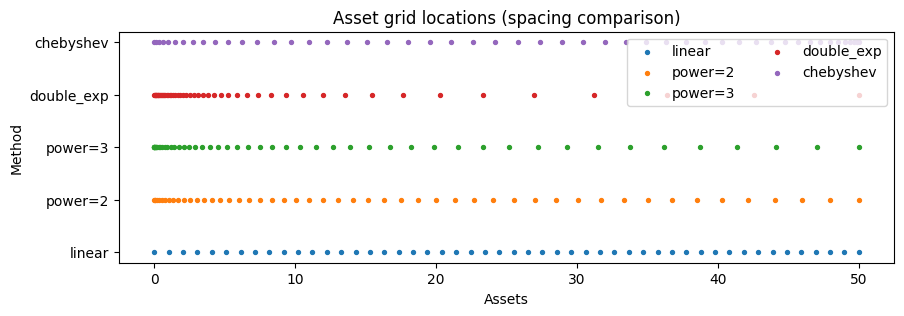

In [11]:
amin, amax, n = 0.0, 50.0, 50

asset_linear = make_grid_1d(amin, amax, n, spacing="linear")
asset_power2 = make_grid_1d(amin, amax, n, spacing="power", power=2.0)
asset_power3 = make_grid_1d(amin, amax, n, spacing="power", power=3.0)
asset_double = double_exponential_grid(amin, amax, n)
asset_cheb = make_grid_1d(amin, amax, n, spacing="chebyshev")

methods = {
    "linear": asset_linear,
    "power=2": asset_power2,
    "power=3": asset_power3,
    "double_exp": asset_double,
    "chebyshev": asset_cheb,
}

fig, ax = plt.subplots(figsize=(10, 3))
for i, (name, grid) in enumerate(methods.items()):
    ax.scatter(grid, np.full_like(grid, i), s=8, label=name)

ax.set_yticks(range(len(methods)))
ax.set_yticklabels(list(methods.keys()))
ax.set_title("Asset grid locations (spacing comparison)")
ax.set_xlabel("Assets")
ax.set_ylabel("Method")
ax.legend(loc="upper right", ncol=2)
plt.show()

## 2. Concentration points

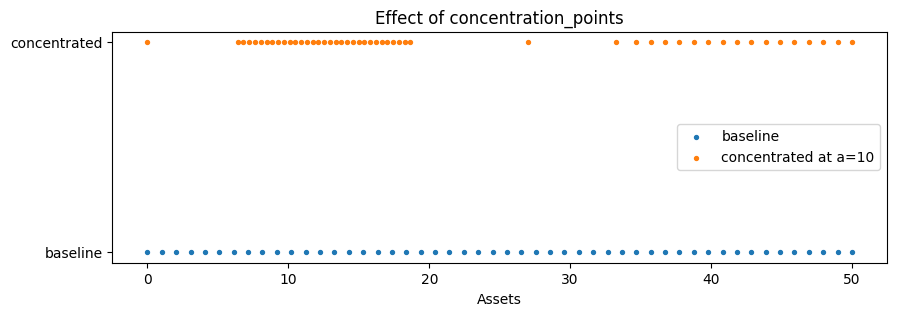

In [12]:
base = make_grid_1d(0.0, 50.0, 50, spacing="linear")
concentrated = make_grid_1d(
    0.0,
    50.0,
    50,
    spacing="linear",
    concentration_points=[10.0],
    concentration_weight=0.6,
    concentration_radius=3.0,
)

fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(base, np.zeros_like(base), s=8, label="baseline")
ax.scatter(concentrated, np.ones_like(concentrated), s=8, label="concentrated at a=10")
ax.set_yticks([0, 1])
ax.set_yticklabels(["baseline", "concentrated"])
ax.set_xlabel("Assets")
ax.set_title("Effect of concentration_points")
ax.legend()
plt.show()

## 3. Income grids (1D): log-spaced vs Chebyshev

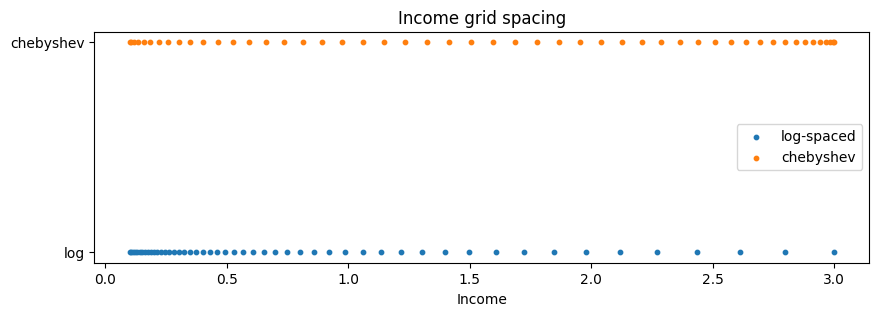

In [13]:
# Positive income grid for log spacing
y_log = log_spaced_grid(0.1, 3.0, 50)

# Chebyshev nodes on a bounded income range
y_cheb = make_grid_1d(0.1, 3.0, 50, spacing="chebyshev")

fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(y_log, np.zeros_like(y_log), s=10, label="log-spaced")
ax.scatter(y_cheb, np.ones_like(y_cheb), s=10, label="chebyshev")
ax.set_yticks([0, 1])
ax.set_yticklabels(["log", "chebyshev"])
ax.set_xlabel("Income")
ax.set_title("Income grid spacing")
ax.legend()
plt.show()

## 4. 2D grid: Cartesian product

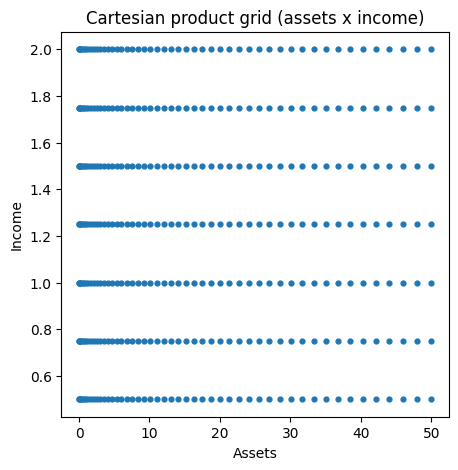

In [14]:
specs = [
    GridSpec(lower=0.0, upper=50.0, n_points=50, spacing="power", power=2.0),
    GridSpec(lower=0.5, upper=2.0, n_points=7, spacing="linear"),
]

(grids, cart) = make_grid_nd(specs, cartesian=True)
a_grid, y_grid = grids

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(cart[:, 0], cart[:, 1], s=12)
ax.set_xlabel("Assets")
ax.set_ylabel("Income")
ax.set_title("Cartesian product grid (assets x income)")
plt.show()

## 5. 2D grid: Tensor product

Tensor shape: (50, 7, 2)


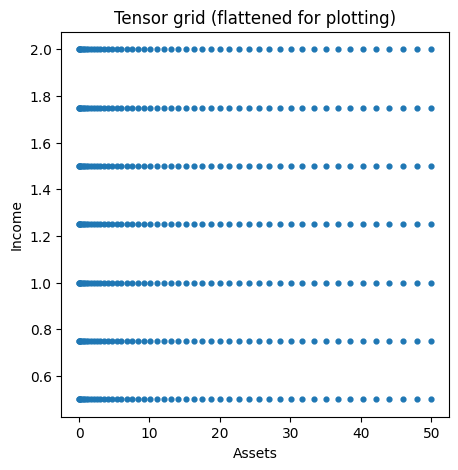

In [15]:
(grids, tensor) = make_grid_nd(specs, tensor=True)
print("Tensor shape:", tensor.shape)  # (n_a, n_y, 2)

# Flatten for plotting
coords = tensor.reshape(-1, 2)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(coords[:, 0], coords[:, 1], s=12)
ax.set_xlabel("Assets")
ax.set_ylabel("Income")
ax.set_title("Tensor grid (flattened for plotting)")
plt.show()

## 6. Tensor vs Smolyak (2D comparison)

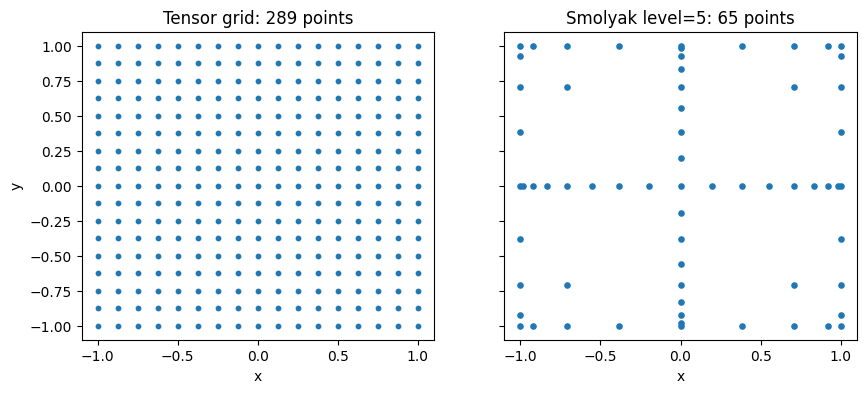

In [16]:
# Tensor grid
specs_2d = [
    GridSpec(lower=-1.0, upper=1.0, n_points=17, spacing="linear"),
    GridSpec(lower=-1.0, upper=1.0, n_points=17, spacing="linear"),
]

_, tensor_2d = make_grid_nd(specs_2d, tensor=True)
pts_tensor = tensor_2d.reshape(-1, 2)

# Smolyak grid
pts_smolyak = smolyak_sparse_grid(specs_2d, level=5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
axes[0].scatter(pts_tensor[:, 0], pts_tensor[:, 1], s=10)
axes[0].set_title(f"Tensor grid: {pts_tensor.shape[0]} points")
axes[1].scatter(pts_smolyak[:, 0], pts_smolyak[:, 1], s=14)
axes[1].set_title(f"Smolyak level=5: {pts_smolyak.shape[0]} points")

for ax in axes:
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.show()

## 7. Smolyak levels (2D)

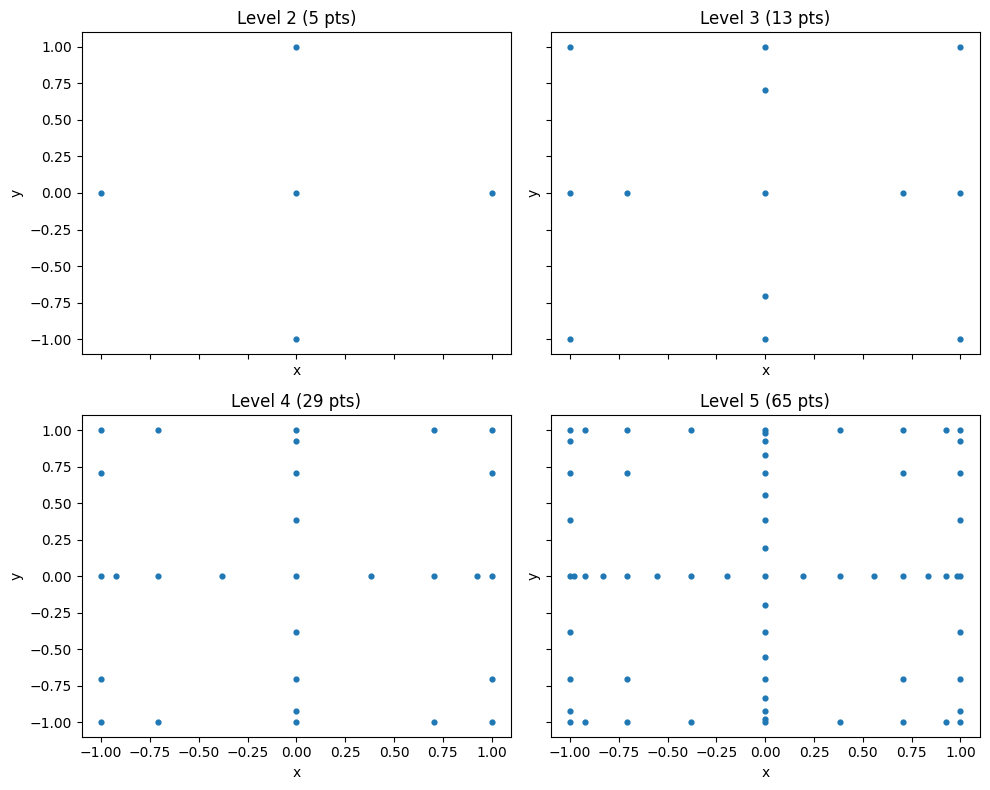

In [17]:
levels = [2, 3, 4, 5]
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

for ax, lvl in zip(axes.ravel(), levels):
    pts = smolyak_sparse_grid(specs_2d, level=lvl)
    ax.scatter(pts[:, 0], pts[:, 1], s=12)
    ax.set_title(f"Level {lvl} ({pts.shape[0]} pts)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

## 8. Higher dimensions: point counts

In [18]:
# 3D tensor vs Smolyak
specs_3d = [
    GridSpec(lower=-1.0, upper=1.0, n_points=9, spacing="linear"),
    GridSpec(lower=-1.0, upper=1.0, n_points=9, spacing="linear"),
    GridSpec(lower=-1.0, upper=1.0, n_points=9, spacing="linear"),
]

_, tensor_3d = make_grid_nd(specs_3d, tensor=True)
pts_tensor_3d = tensor_3d.reshape(-1, 3)
pts_smolyak_3d = smolyak_sparse_grid(specs_3d, level=3)

print("Tensor 3D points:", pts_tensor_3d.shape[0])
print("Smolyak level=3 points:", pts_smolyak_3d.shape[0])

Tensor 3D points: 729
Smolyak level=3 points: 25
